#A model that takes a image and preeicts Age and Gender

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d jangedoo/utkface-new --unzip

Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
100% 331M/331M [00:02<00:00, 165MB/s]



In [ ]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
folder_path = '/content/utkface_aligned_cropped/UTKFace'

In [ ]:
age =[]
gender = []
img_path = []

#Our file name consists of age, gender and ethinicity separated by underscores
for file in os.listdir(folder_path):    # os.listdir(folder_path) gives you all files/folders inside folder_path.
  age.append(int(file.split('_')[0]))       # Extract age from file name
  gender.append(int(file.split('_')[1]))    # Extract gender from file name
  img_path.append(os.path.join(folder_path,file))   # img_path stores where the image actually is.

'''
img path stores something like this
[
 '/content/UTKFace/25_0_12345.jpg',
 '/content/UTKFace/32_1_45678.jpg',
 '/content/UTKFace/18_0_78910.jpg',
 '/content/UTKFace/45_1_11111.jpg'
]
'''

"      \nimg path stores something like this\n[                                          \n '/content/UTKFace/25_0_12345.jpg',\n '/content/UTKFace/32_1_45678.jpg',\n '/content/UTKFace/18_0_78910.jpg',\n '/content/UTKFace/45_1_11111.jpg'\n]\n"

In [ ]:
df = pd.DataFrame({
    'age': age,
    'gender': gender,
    'img': img_path
    })

df.shape

(23708, 3)

In [ ]:
df.head()

,age,gender,img
0,28,1,/content/utkface_aligned_cropped/UTKFace/28_1_...
1,29,0,/content/utkface_aligned_cropped/UTKFace/29_0_...
2,1,1,/content/utkface_aligned_cropped/UTKFace/1_1_0...
3,34,0,/content/utkface_aligned_cropped/UTKFace/34_0_...
4,70,0,/content/utkface_aligned_cropped/UTKFace/70_0_...


In [ ]:
train_df = df.sample(frac = 1,random_state=0).iloc[:20000]
test_df = df.sample(frac = 1, random_state=0).iloc[20000:]

In [ ]:
print(train_df.shape)
print(test_df.shape)

(20000, 3)
(3708, 3)


In [ ]:
# Data Augumentation

train_datagen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 30,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True
)

test_datagen = ImageDataGenerator(rescale = 1./255)


In [ ]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    directory = folder_path,
    x_col = 'img',
    y_col = ['age','gender'],     # here we give both outputs
    target_size = (200,200),
    class_mode = 'multi_output',
    batch_size = 32
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    directory = folder_path,
    x_col = 'img',
    y_col = ['age','gender'],
    target_size = (200,200),
    class_mode = 'multi_output',
    batch_size = 32
)

Found 20000 validated image filenames.
Found 3708 validated image filenames.


In [ ]:
from keras.applications.vgg16 import VGG16
from keras.layers import *
from keras.models import Model

In [ ]:
vggnet = VGG16(include_top = False, weights= 'imagenet', input_shape = (200,200,3))

vggnet.trainable = False

output = vggnet.layers[-1].output

flatten = Flatten()(output)

dense1 = Dense(512,activation = 'relu')(flatten)
dense2 = Dense(512,activation = 'relu')(flatten)

dense3 = Dense(512,activation = 'relu')(dense1)
dense4 = Dense(512,activation = 'relu')(dense2)

output1 = Dense(1,activation = 'linear',name = 'age')(dense3)
output2 = Dense(1,activation = 'sigmoid',name = 'gender')(dense4)

model = Model(inputs = vggnet.input,outputs = [output1, output2])
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 200, 200,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 200, 200,  │      1,792 │ input_layer[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 200, 200,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 100, 100,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 100, 100,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 100, 100,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 50, 50,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 50, 50,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 50, 50,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 50, 50,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 25, 25,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 25, 25,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 25, 25,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 25, 25,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 12, 12,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 12, 12,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 12, 12,    │  2,359,808 │ block5_conv1[0][

 Total params: 34,116,418 (130.14 MB)

 Trainable params: 19,401,730 (74.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

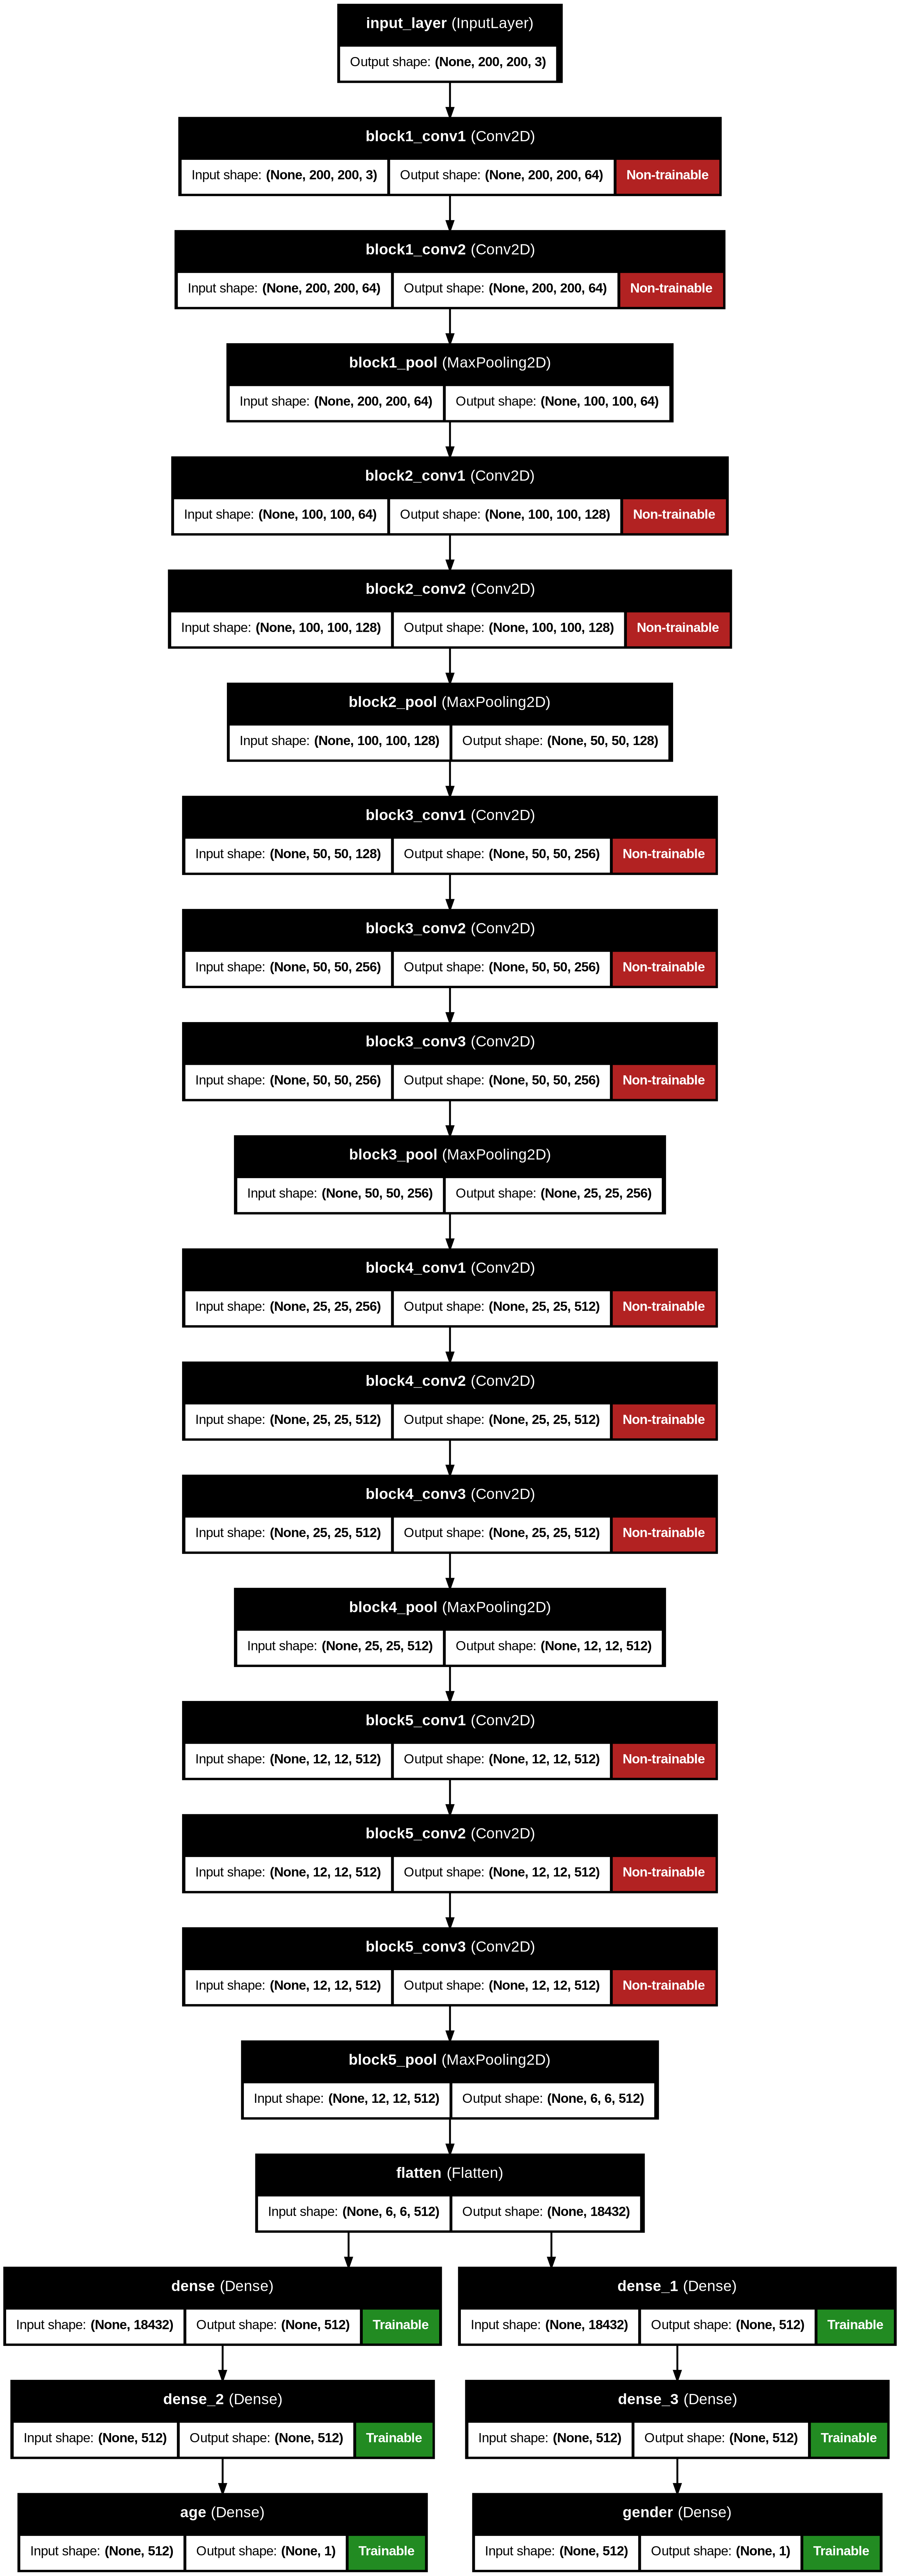

In [ ]:
from keras.utils import plot_model
plot_model(model, show_shapes=True, show_layer_names=True, show_trainable=True)

In [ ]:
model.compile(
    optimizer = 'adam',
    loss = {'age': 'mae', 'gender': 'binary_crossentropy'},
    metrics = {'age': 'mae', 'gender': 'accuracy'},
    loss_weights = {'age': 1, 'gender': 99}
    )

In [ ]:
def generator_wrapper(generator):
    while True:
        x, y = next(generator)
        yield x, tuple(y)

train_gen = generator_wrapper(train_generator)
test_gen = generator_wrapper(test_generator)

In [ ]:
history = model.fit(train_gen, epochs = 10, validation_data = test_gen)

Epoch 1/10
    108/Unknown 1950s 18s/step - age_loss: 14.6881 - age_mae: 14.6881 - gender_accuracy: 0.6263 - gender_loss: 0.9149 - loss: 105.2641

KeyboardInterrupt: 